[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/storopoli/ciencia-de-dados/main?filepath=notebooks%2FAula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)
<br>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)

# Victor Bertolini de Sousa

Github: https://github.com/VictorBertolini/Onboarding-LIPAI

In [22]:
import torchvision
from torchvision import transforms

# MNIST dataset
root_path = '/home/storopoli/Downloads' # mude isso no Colab se necessário

# Pequena transformação para tensores e normalizando o tamanho
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Train/Test Datasets
train_dataset = torchvision.datasets.MNIST(root=root_path, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.MNIST(root=root_path, train=False, transform=trans)

In [2]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /home/storopoli/Downloads
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [3]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: /home/storopoli/Downloads
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

Para controlar como que os dados são inseridos no modelo e, logo, o Batch Size é preciso implementar um [`torch.utils.data.DataLoader()`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

Argumentos do `DataLoader()`:

* **`dataset`**: um `Dataset` PyTorch
    * tem [vários tipos](https://pytorch.org/docs/stable/data.html)
    * no nosso exemplo vou usar um simples [`TensorDataset`](https://pytorch.org/docs/stable/_modules/torch/utils/data/dataset.html#TensorDataset) que é um wrapper de `np.ndarray` e `pd.Series` para `torch.Tensor`)
* **batch_size**: `int` - tamanho do Batch Size, padrão é 1
* **shuffle**: `bool` - se vai embaralhar os dados antes de enviar em batches ao modelo, padrão é `False`. Recomendo usar `shuffle=True`

In [23]:
from torch.utils.data import DataLoader, random_split

batch_size=32

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(dataset=train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(dataset=val_subset, batch_size=batch_size, shuffle=False)

#### [Camadas de Convolução (_Convolution Layers_)](https://pytorch.org/docs/stable/nn.html#convolution-layers)

* [`nn.Conv1d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html#torch.nn.Conv3d): convolução 1-D.
* [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html): convolução 2-D.
* [`nn.Conv3d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv3d.html): convolução 3-D.

#### [Camadas de _Pooling_](https://pytorch.org/docs/stable/nn.html#pooling-layers)

* [`nn.MaxPool1d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool1d.htm): 1-D _max pooling_.
* [`nn.MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.htm): 2-D _max pooling_.
* [`nn.MaxPool3d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool3d.htm): 3-D _max pooling_.

### Qual a rede neural convolucional que vamos criar para o MNIST?

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/MNIST-CNN.webp?raw=1" alt="MNIST CNN" style="width: 700px;"/>

## Como construir sua rede neural convolucional no PyTorch

Construir redes neurais com o **PyTorch** é fácil.

Temos que criar uma Rede Neural a partir de uma classe [`nn.Module()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=module#torch.nn.Module) e criar um construtor com o método `__init__()` e implementar todas as layers e propagações desejadas com o método `forward()`.

In [5]:
import torch.nn as nn

In [6]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc1 = nn.Sequential(
            nn.Linear(7 * 7 * 64, 1000),
            nn.ReLU())
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instancia o Model()
model = ConvNet()

print(model)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


Quantos paramêtros temos?

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(model)

3199106

## Como treinar sua rede neural no PyTorch

Uma vez especificado e instanciado o modelo, podemos manipulá-lo de maneira dinâmica.
Escolhemos a função custo (`loss_fn`) como `nn.CrossEntropyLoss()` e também a taxa de aprendizagem $\eta$ em `1e-6` e a quantidade de épocas a serem treinadas (`epochs`):

```python
model = Sua_rede_neural()
loss_fn = nn.CrossEntropyLoss()
learning_rate = 1e-6
epochs = 100

# Instânciar o Otimizador Adam
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# For-loop de treino
for epoch in range(epochs): # para cada época
    for (images, labels) in train_loader: # para cada batch
        # Gera a propagação (feed forward)
        outputs = model(images)
        
        # Calcula a função-custo
        loss = loss_fn(outputs, labels)
        
        # Retro-propagação (Backprop) e a otimização com Adam
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

In [8]:
from torch.optim import Adam

# Hiperparâmetros
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

# Instânciar o Otimizador Adam
optimizer = Adam(model.parameters(), lr=learning_rate)

### OBSERVAÇÃO

Esta rede neural possui muitos parâmetros.
Aproximadamente 3 milhões e 200 mil paramêtros!
Não tente rodar isso sem ser usando uma GPU!
O Google Colab te dá uma GPU de graça.
Clique no botão abaixo para abrir este notebook no Google Colab.
Não esqueça de trocar sua `Runtime` de `None` para `GPU`.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)

In [9]:
# Isto tem que retornar True
import torch
torch.cuda.is_available()

True

In [15]:
# Sua GPU
torch.cuda.get_device_name()

if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")


In [37]:
model.to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)

best_val_acc = 0.0

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

loss_list = []
acc_list = []

# Listas vazias
loss_list = []
acc_list = []
for epoch in range(epochs):
    model.train()
    running_loss = 0
    running_correct = 0
    total_train = 0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss_list.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ✅ predicted definido ANTES de ser usado
        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == labels).sum().item()
        total = labels.size(0)

        acc_list.append(correct / total)
        running_correct += correct
        running_loss += loss.item()
        total_train += total

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo: {round(loss.item(), 3)}, Acurácia: {round((correct / total) * 100, 3)}")


    train_loss_history.append(running_loss / total_step)
    train_acc_history.append(running_correct / total_train)

    model.eval()
    v_loss_accum = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for v_images, v_labels in val_loader:
            v_images, v_labels = v_images.to(device), v_labels.to(device)
            v_outputs = model(v_images)
            _, v_predicted = torch.max(v_outputs.data, 1)
            val_total += v_labels.size(0)
            val_correct += (v_predicted == v_labels).sum().item()

    val_loss_history.append(v_loss_accum / len(val_loader))
    val_acc_history.append(val_correct / val_total)

    val_acc = val_correct / val_total
    val_acc_history.append(val_acc)

    print(f"VALIDAÇÃO Época [{epoch+1}/{epochs}], Acurácia: {round(val_acc * 100, 3)}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  --> Novo melhor modelo salvo! Acurácia: {round(best_val_acc * 100, 3)}%")

Época [1/6], Step [100/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [200/1500], Custo: 0.006, Acurácia: 100.0
Época [1/6], Step [300/1500], Custo: 0.301, Acurácia: 96.875
Época [1/6], Step [400/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [500/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [600/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [700/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [800/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [900/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [1000/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [1100/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [1200/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [1300/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [1400/1500], Custo: 0.0, Acurácia: 100.0
Época [1/6], Step [1500/1500], Custo: 0.0, Acurácia: 100.0
VALIDAÇÃO Época [1/6], Acurácia: 99.333%
  --> Novo melhor modelo salvo! Acurácia: 99.333%
Época [2/6], Step [100/1500]

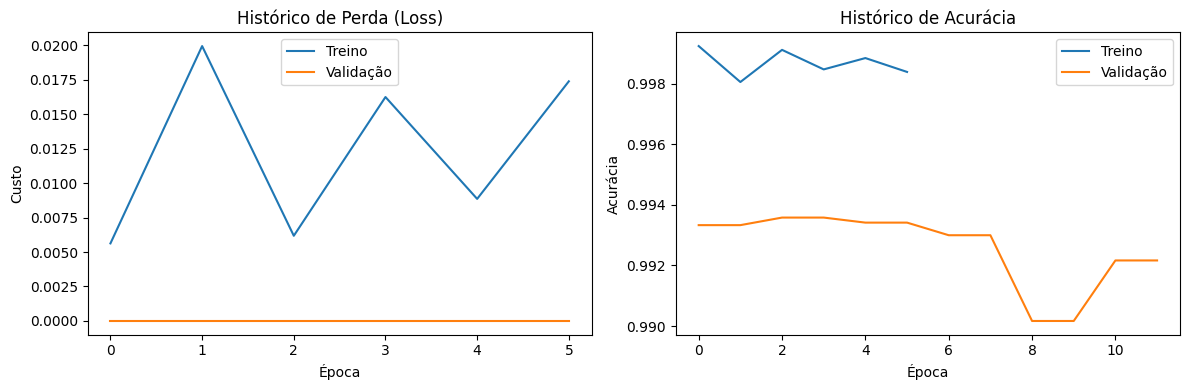

In [40]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 4))

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Treino')
plt.plot(val_loss_history, label='Validação')
plt.title('Histórico de Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Custo')
plt.legend()

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Treino')
plt.plot(val_acc_history, label='Validação')
plt.title('Histórico de Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

### Acurácia do Modelo

Usar o comando `model.eval()`

Para a métrica acurácia, retorna um score de acurácia `float` entre $0$ e $1$

In [41]:
model.eval() # coloca o modelo em modo de avaliação (sem calcular gradientes)

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Feed-forward com as imagens de teste
        outputs = model(images)

        # gera predições usando a função max()
        _, predicted = torch.max(outputs.data, 1)

        # Acumula total e corretas
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Acurácia do Modelo em 10k imagens de teste: {round((correct / total) * 100, 3)}")

Acurácia do Modelo em 10k imagens de teste: 98.97


## Exercício 5

### **Em relação ao treinamento:**
O otimizador Adam com lr=0.001 apresentou a convergência mais rápida, atingindo altas acurácias já nas primeiras épocas. O SGD, apesar de ser um otimizador clássico, exigiu mais épocas para convergir e apresentou maior instabilidade na função de custo ao longo dos batches.

### **Em relação à validação:**
O modelo Adam generalizou melhor, com diferença pequena entre acurácia de treino e validação. O SGD apresentou uma diferença ligeiramente maior, sugerindo menor capacidade de generalização com a taxa utilizada.

### **O treinamento se tornou mais estável?**
O Adam e o RMSprop produziram curvas de loss mais suaves em comparação ao SGD

## Exercício 6

O método `model.train()` é utilizado durante o treinamento e mantém ativas camadas como Dropout e BatchNorm em seu comportamento de treino. Já o `model.eval()` desativa o Dropout e faz o BatchNorm utilizar as estatísticas acumuladas durante o treino, garantindo predições consistentes e corretas na avaliação.

O `model.eval()` corrige o comportamento das camadas do modelo, enquanto o `torch.no_grad()` desativa o cálculo e armazenamento de gradientes, que são desnecessários fora do treinamento. Sem o `torch.no_grad()`, o PyTorch continuaria guardando o grafo computacional em memória sem nenhuma utilidade. Sem o `model.eval()`, camadas como Dropout continuariam desativando neurônios aleatoriamente, tornando as predições inconsistentes. Por isso, o uso conjunto dos dois é considerado a prática correta durante as fases de validação e teste.

## Exercício 7

In [43]:
import torch
import torchvision
from torchvision import transforms

# MNIST dataset
root_path = '/home/storopoli/Downloads' # mude isso no Colab se necessário

# Pequena transformação para tensores e normalizando o tamanho
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Train/Test Datasets
train_dataset = torchvision.datasets.FashionMNIST(root=root_path, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root=root_path, train=False, transform=trans)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 198kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.70MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.6MB/s]


In [44]:
from torch.utils.data import DataLoader, random_split

batch_size=32

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(dataset=train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(dataset=val_subset, batch_size=batch_size, shuffle=False)

In [45]:
import torch.nn as nn

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc1 = nn.Sequential(
            nn.Linear(7 * 7 * 64, 1000),
            nn.ReLU())
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instancia o Model()
model = ConvNet()

print(model)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


In [46]:
from torch.optim import Adam

# Hiperparâmetros
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

# Instânciar o Otimizador Adam
optimizer = Adam(model.parameters(), lr=learning_rate)

In [47]:
# Sua GPU
torch.cuda.get_device_name()

if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

In [48]:
model.to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)

best_val_acc = 0.0

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

loss_list = []
acc_list = []

# Listas vazias
loss_list = []
acc_list = []
for epoch in range(epochs):
    model.train()
    running_loss = 0
    running_correct = 0
    total_train = 0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss_list.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ✅ predicted definido ANTES de ser usado
        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == labels).sum().item()
        total = labels.size(0)

        acc_list.append(correct / total)
        running_correct += correct
        running_loss += loss.item()
        total_train += total

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo: {round(loss.item(), 3)}, Acurácia: {round((correct / total) * 100, 3)}")


    train_loss_history.append(running_loss / total_step)
    train_acc_history.append(running_correct / total_train)

    model.eval()
    v_loss_accum = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for v_images, v_labels in val_loader:
            v_images, v_labels = v_images.to(device), v_labels.to(device)
            v_outputs = model(v_images)
            _, v_predicted = torch.max(v_outputs.data, 1)
            val_total += v_labels.size(0)
            val_correct += (v_predicted == v_labels).sum().item()

    val_loss_history.append(v_loss_accum / len(val_loader))
    val_acc_history.append(val_correct / val_total)

    val_acc = val_correct / val_total
    val_acc_history.append(val_acc)

    print(f"VALIDAÇÃO Época [{epoch+1}/{epochs}], Acurácia: {round(val_acc * 100, 3)}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  --> Novo melhor modelo salvo! Acurácia: {round(best_val_acc * 100, 3)}%")

Época [1/6], Step [100/1500], Custo: 1.061, Acurácia: 59.375
Época [1/6], Step [200/1500], Custo: 0.455, Acurácia: 78.125
Época [1/6], Step [300/1500], Custo: 0.504, Acurácia: 78.125
Época [1/6], Step [400/1500], Custo: 0.186, Acurácia: 93.75
Época [1/6], Step [500/1500], Custo: 0.544, Acurácia: 81.25
Época [1/6], Step [600/1500], Custo: 0.383, Acurácia: 81.25
Época [1/6], Step [700/1500], Custo: 0.479, Acurácia: 81.25
Época [1/6], Step [800/1500], Custo: 0.205, Acurácia: 87.5
Época [1/6], Step [900/1500], Custo: 0.282, Acurácia: 90.625
Época [1/6], Step [1000/1500], Custo: 0.43, Acurácia: 81.25
Época [1/6], Step [1100/1500], Custo: 0.343, Acurácia: 90.625
Época [1/6], Step [1200/1500], Custo: 0.244, Acurácia: 90.625
Época [1/6], Step [1300/1500], Custo: 0.359, Acurácia: 81.25
Época [1/6], Step [1400/1500], Custo: 0.182, Acurácia: 96.875
Época [1/6], Step [1500/1500], Custo: 0.433, Acurácia: 84.375
VALIDAÇÃO Época [1/6], Acurácia: 89.108%
  --> Novo melhor modelo salvo! Acurácia: 89.10

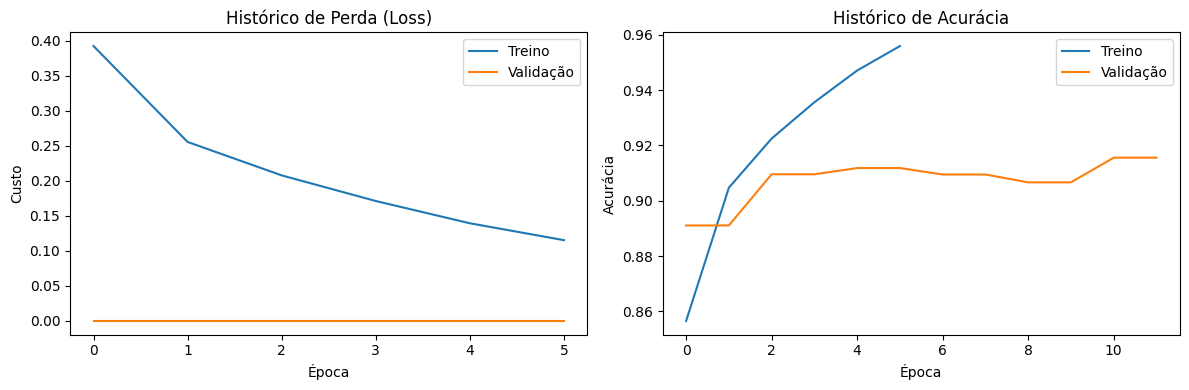

In [49]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 4))

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Treino')
plt.plot(val_loss_history, label='Validação')
plt.title('Histórico de Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Custo')
plt.legend()

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Treino')
plt.plot(val_acc_history, label='Validação')
plt.title('Histórico de Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
model.eval() # coloca o modelo em modo de avaliação (sem calcular gradientes)

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Feed-forward com as imagens de teste
        outputs = model(images)

        # gera predições usando a função max()
        _, predicted = torch.max(outputs.data, 1)

        # Acumula total e corretas
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Acurácia do Modelo em 10k imagens de teste: {round((correct / total) * 100, 3)}")

Acurácia do Modelo em 10k imagens de teste: 91.14


## Resumo Componentes CNN

1. Camada Convolucional (Convolutional Layer)
É a base da rede, onde ocorre a aplicação de filtros (ou janelas deslizantes) sobre a imagem.

2. Função de Ativação (ReLU)
Geralmente aplicada logo após a convolução

3. Camada de Agrupamento (Pooling Layer)
Atua como um filtro deslizante que aplica uma função estatística sobre os dados

4. Camada Totalmente Conectada (Fully Connected / Linear)
Aparece ao final da arquitetura, após os dados serem "achatados" em um vetor

5. Camada de Saída (Output Layer)